# 04 · Ước lượng hiệu ứng voucher và ngưỡng căng cung θ̂

Notebook của Hoàng (Sprint 6, H6.2). Kết quả của H5.2 (DR-learner) và H5.3 (chọn ŝ, tác hại theo giờ, θ̂ so với θ\*).
Mọi phép tính nằm trong `analysis/` (có test); notebook chỉ gọi hàm, vẽ hình và giải thích. Quyết định liên quan: H-24, H-25, H-26 trong `docs/decisions.md`.

**Câu hỏi của notebook:**
1. Học được hiệu ứng voucher theo từng rider không, và hàm điểm nào cho nhiều chuyến nhất dưới cùng ngân sách B?
2. Đo "căng cung" bằng chỉ số nào?
3. Voucher gây hại ở đâu, khi nào?
4. Ước lượng ngưỡng θ̂ từ dữ liệu thí nghiệm thế nào, và θ̂ kém ngưỡng tốt nhất θ\* (đo bằng mô phỏng) bao nhiêu?

**Các mục:** 1. DR-learner · 2. Chọn chỉ số căng cung ŝ · 3. Tác hại theo giờ · 4. Ước lượng θ̂ · 5. θ̂ so với θ\* · 6. Kết luận

In [1]:
import numpy as np
import pandas as pd

from analysis import metrics, tension, theta, uplift
from analysis.estimate import experiment_frame, run_config
from analysis.io import load_tables
from analysis.notebook import require_runs, setup
from analysis.plots import GRID, INK, INK_2, MUTED, save_figure, vn
from analysis.policy_table import summarize
from sim.config import load_config

plt = setup()
(ALL_OFF_3D, HOURLY_ON, HOURLY_OFF, SB_ALL, SB_C7, LEGACY, POLICY_TABLE,
 SW_CELL_HEUR, SW_CELL_DR, SW_RING_RANDOM, SW_RING_HEUR, SW_RING_DR) = require_runs(
    "runs/h53/all_off_3d", "runs/h53/hourly_all_on", "runs/h53/hourly_all_off",
    "runs/b7a/switchback_all_28d", "runs/b7a/switchback_c7_28d", "runs/b7a/legacy_28d",
    "runs/s5/policy_table", "runs/b7b_h21/sweep_theta_ref", "runs/s5/sweep_cell_dr",
    "runs/s5/sweep_ring1_random", "runs/s5/sweep_ring1_heuristic", "runs/s5/sweep_ring1_dr")
CFG = load_config("config/default.yaml")
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"     # categorical slots 1-3 of the house palette (analysis/plots.py)


def tex(text: str) -> str:
    # Hats as matplotlib math text: the UI font misplaces the combining circumflex of θ̂ and τ̂.
    return text.replace("θ̂", r"$\hat{\theta}$").replace("τ̂", r"$\hat{\tau}$")

## 1. DR-learner: hiệu ứng voucher theo rider (H5.2, H-24)

Mỗi session có kết cục `Y` (1 nếu chuyến hoàn thành) và `T` (1 nếu được phát voucher). Hiệu ứng của một rider có đặc trưng `x` là
τ(x) = P(Y = 1 | phát, x) − P(Y = 1 | không phát, x). DR-learner (Kennedy 2023) học τ(x) qua *pseudo-outcome*

$$\varphi = \hat\mu_1 - \hat\mu_0 + \frac{T\,(Y-\hat\mu_1)}{\hat e} - \frac{(1-T)\,(Y-\hat\mu_0)}{1-\hat e},$$

với `μ̂₁, μ̂₀` là tỷ lệ hoàn thành dự báo khi có / không voucher và `ê` là xác suất được phát; rồi hồi quy φ theo `x`.
Các mô hình phụ học **chéo 5 phần theo rider** (mọi session của một rider cùng một phần), nên φ của một session không dùng mô hình đã thấy chính nó.

Hai mẫu: `dr_explore` chỉ dùng lát explore (phát ngẫu nhiên, `e = 0,5` đã biết) và `dr_all` dùng toàn bộ dữ liệu legacy (nhiều hơn, nhưng bị nhiễu do biến ẩn `u_latent`).

In [2]:
rows = []
for name in ("dr_explore", "dr_all"):
    meta, _ = uplift.load_model(name)
    rows.append({"mô hình": name, "số session": meta["n"], "được phát": meta["n_treated"],
                 "so thô": meta["ate_naive"], "DR": meta["ate_dr"], "SE (DR)": meta["ate_dr_se"],
                 "% ê bị cắt về [0,02; 0,98]": 100 * meta["share_e_clipped"]})
pd.DataFrame(rows).set_index("mô hình").round(4)

,số session,được phát,so thô,DR,SE (DR),"% ê bị cắt về [0,02; 0,98]"
mô hình,,,,,,
dr_explore,35959,17858,0.0695,0.0697,0.0037,0.0000
dr_all,717914,166616,0.1019,0.1010,0.0009,33.4692


Hiệu ứng trung bình lên tỷ lệ hoàn thành:
- **Lát explore:** DR ≈ so thô ≈ 0,070, đúng như kỳ vọng vì voucher được phát ngẫu nhiên.
- **Toàn bộ legacy:** DR ≈ so thô ≈ 0,101, **cao hơn lát explore khoảng 0,03**. Luật phát voucher cũ ưu tiên rider có `u_latent` cao, mà biến này không có trong dữ liệu quan sát, nên DR không gỡ được phần nhiễu này (chi tiết ở notebook 05).

Vì vậy hàm điểm học trên `dr_all` xếp hạng rider *có thể* lệch. Mục dưới kiểm tra điều đó bằng chỉ tiêu thật: số chuyến dưới cùng ngân sách.

WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/04_tau_x_theo_rider.png')

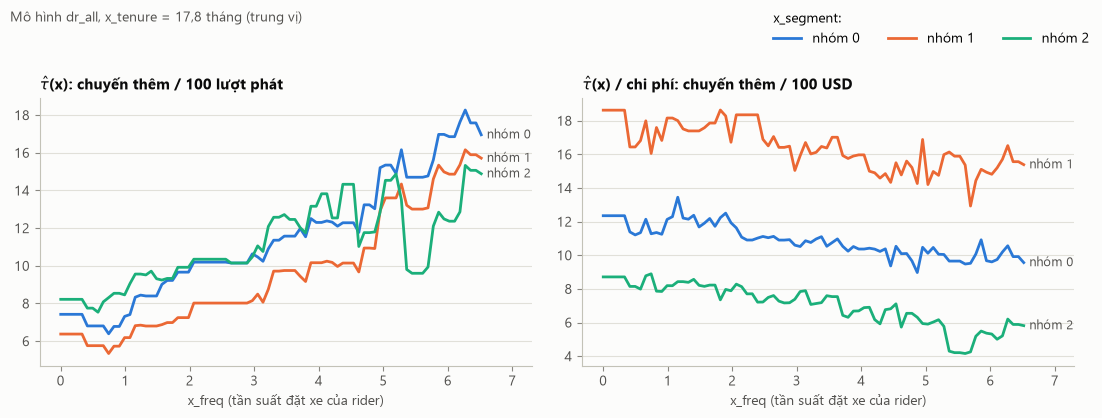

In [3]:
riders = load_tables(LEGACY, ["observed/riders"])["riders"]
grid = np.linspace(0.0, float(riders["x_freq"].quantile(0.99)), 80)
tenure = float(riders["x_tenure"].median())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for seg, color in zip(range(3), (C1, C2, C3)):
    feats = {"x_freq": grid, "x_tenure": np.full_like(grid, tenure), "x_segment": np.full_like(grid, seg),
             "slack_lag_slot": np.zeros_like(grid)}
    pred = uplift.predict_scores("dr_all", feats)
    for ax, key, scale in ((axes[0], "tau_x", 100.0), (axes[1], "tau_x_per_dollar", 100.0)):
        y = scale * pred[key]
        ax.plot(grid, y, color=color, linewidth=2, label=f"nhóm {seg}")
        ax.annotate(f"nhóm {seg}", xy=(grid[-1], y[-1]), xytext=(4, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
axes[0].set_title(tex("τ̂(x): chuyến thêm / 100 lượt phát"))
axes[1].set_title(tex("τ̂(x) / chi phí: chuyến thêm / 100 USD"))
for ax in axes:
    ax.set_xlabel("x_freq (tần suất đặt xe của rider)")
    ax.set_xlim(right=grid[-1] * 1.12)                       # room for the direct labels
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, frameon=False, loc="upper right", ncol=3, title="x_segment:", alignment="left")
fig.suptitle(f"Mô hình dr_all, x_tenure = {vn(tenure, 1)} tháng (trung vị)", x=0.01, ha="left", color=INK_2, fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.93))
save_figure(fig, "04_tau_x_theo_rider")

Hai cách xếp hạng rider ngược nhau:
- **Theo lượt phát** (trái): rider đặt xe nhiều có hiệu ứng mỗi lượt phát cao.
- **Theo mỗi USD** (phải): rider đặt xe nhiều lại kém nhất, vì họ đi chuyến dài hơn nên voucher 20% giá cuốc đắt hơn, và nhiều chuyến của họ đằng nào cũng diễn ra.

Ngân sách B tính bằng USD, nên xếp hạng theo mỗi USD mới đúng mục tiêu. Bảng dưới đo trực tiếp: mọi hàm điểm chạy dưới cùng B, cùng 30 seed (bảng T5.1 của Tình, θ = 0 nên chỉ khác nhau ở việc phát cho ai), so với phát ngẫu nhiên.

In [4]:
labels = pd.read_parquet(POLICY_TABLE / "results" / "policy_labels.parquet")
policy_runs = pd.read_parquet(POLICY_TABLE / "results" / "policy_results.parquet").merge(labels, on="run_id")
B = float(policy_runs["budget_B_usd"].max())
SCORES = {"random": "ngẫu nhiên", "heuristic": "heuristic (ưu tiên tần suất thấp)",
          "tau_x": "τ̂(x) nền (bảng)", "tau_per_usd": "τ̂(x)/USD nền (bảng)",
          "tau_x_dr_usd": "τ̂(x)/USD DR, explore", "tau_xs_dr_usd": "τ̂(x, s)/USD DR, explore",
          "tau_x_dr_all": "τ̂(x) DR, toàn bộ", "tau_xs_dr_all": "τ̂(x, s) DR, toàn bộ",
          "tau_x_dr_all_usd": "τ̂(x)/USD DR, toàn bộ", "tau_xs_dr_all_usd": "τ̂(x, s)/USD DR, toàn bộ"}
by_score = summarize(policy_runs, reference="random", order=list(SCORES)).set_index("label")
by_score = by_score.assign(tên=pd.Series(SCORES)).sort_values("dN_vs_ref")
by_score[["tên", "N_mean", "N_se", "dN_vs_ref", "dN_vs_ref_se", "spent_mean"]].round(1)

,tên,N_mean,N_se,dN_vs_ref,dN_vs_ref_se,spent_mean
label,,,,,,
tau_x_dr_all,"τ̂(x) DR, toàn bộ",3752.7,10.6,-54.3,5.1,5528.9
tau_xs_dr_all,"τ̂(x, s) DR, toàn bộ",3780.3,10.4,-26.7,5.3,5473.0
tau_x,τ̂(x) nền (bảng),3803.7,10.5,-3.3,5.4,5503.1
random,ngẫu nhiên,3807.0,11.2,0.0,0.0,5451.7
heuristic,heuristic (ưu tiên tần suất thấp),3860.3,11.0,53.2,4.3,5523.3
tau_xs_dr_usd,"τ̂(x, s)/USD DR, explore",3929.2,12.1,122.2,4.5,5413.8
tau_x_dr_usd,"τ̂(x)/USD DR, explore",3934.9,10.3,127.9,4.5,5511.4
tau_x_dr_all_usd,"τ̂(x)/USD DR, toàn bộ",3989.9,10.1,182.9,5.1,5479.6
tau_per_usd,τ̂(x)/USD nền (bảng),4002.0,10.1,195.0,3.9,5481.4


WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/04_n_duoi_b_theo_diem.png')

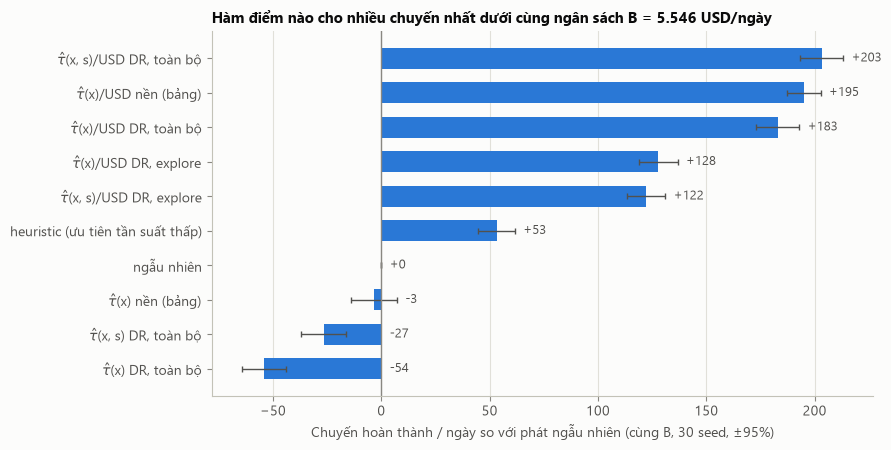

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(by_score))
d, se = by_score["dN_vs_ref"].to_numpy(), by_score["dN_vs_ref_se"].to_numpy()
ax.barh(y, d, xerr=1.96 * se, color=C1, height=0.6, error_kw={"ecolor": INK_2, "elinewidth": 1, "capsize": 2})
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_yticks(y, [tex(n) for n in by_score["tên"]])
for yi, v, s in zip(y, d, se):
    ax.annotate(f"{v:+.0f}", xy=(max(v + 1.96 * s, 0), yi), xytext=(6, 0), textcoords="offset points", va="center",
                color=INK_2, fontsize=9)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=GRID)
ax.set_xlabel("Chuyến hoàn thành / ngày so với phát ngẫu nhiên (cùng B, 30 seed, ±95%)")
ax.set_title(f"Hàm điểm nào cho nhiều chuyến nhất dưới cùng ngân sách B = {vn(B)} USD/ngày")
fig.tight_layout()
save_figure(fig, "04_n_duoi_b_theo_diem")

- Mọi điểm **theo mỗi USD** đều hơn phát ngẫu nhiên rõ rệt; mọi điểm **theo lượt phát** đều không hơn phát ngẫu nhiên (DR theo lượt phát còn thua hẳn).
- Học trên toàn bộ legacy (`_all`) tốt hơn chỉ lát explore: nhiều dữ liệu hơn, và phần nhiễu do `u_latent` không đảo thứ hạng giữa các rider.
- Thêm slack của ô `s` vào điểm (τ̂(x, s)/USD) giúp thêm một ít; bảng dưới so ghép cặp với **`tau_x_dr_all_per_dollar`**, cùng với chính sách khuyến nghị (mục 6), cũng dùng τ̂(x)/USD nhưng thêm tầng ô.

In [6]:
pair = summarize(policy_runs, reference="tau_x_dr_all_usd",
                 order=["tau_x_dr_all_usd", "tau_xs_dr_all_usd", "pi_thetahatA_ring1_dr_usd"]).set_index("label")
pair[["N_mean", "dN_vs_ref", "dN_vs_ref_se"]].round(1)

,N_mean,dN_vs_ref,dN_vs_ref_se
label,,,
tau_x_dr_all_usd,3989.9,0.0,0.0
tau_xs_dr_all_usd,4010.3,20.4,4.9
pi_thetahatA_ring1_dr_usd,4011.8,21.8,4.6


Dùng slack (qua điểm τ̂(x, s), ô theo slack của chính nó, θ = 0) và dùng tầng ô `ring1` ở θ̂ (A) (điểm τ̂(x)) cho **lợi ích ngang nhau**, khoảng +20 chuyến/ngày. Ở H5.2 mình kết luận thêm `s` không giúp gì, dựa trên 10 seed không ghép cặp; với 30 seed ghép cặp kết luận đó sai (đính chính H-28). Kết hợp cả hai (học lại τ̂(x, s) trên slack `ring1` rồi chạy cùng tầng ô) **chưa thử**: τ̂(x, s) hiện học trên slack của ô, nên không dùng được với `ring1` (T-35 b).

## 2. Đo "căng cung" bằng chỉ số nào? (H5.3, H-22, H-25)

Tầng ô của chính sách tắt voucher khi chỉ số căng ŝ < θ. Quy tắc H-22: chọn ŝ theo khả năng **dự báo mức phục vụ** (ETA báo cho khách, `no_supply`) trên dữ liệu `all_off`, **không** nhìn số chuyến (để không chọn ŝ theo chính kết quả cần đo). Mọi ứng viên chỉ dùng dữ liệu đã công bố trước slot của session.

| Ứng viên | Định nghĩa |
|---|---|
| `cell_persistence` | slack (xe rảnh / xe đang đi đón) của ô đón, slot trước (mặc định của spec) |
| `cell_ar` | trung bình có trọng số slot trước và cùng slot hôm trước |
| `cell_idle` | số xe rảnh của ô, slot trước |
| **`ring1`** | (Σ xe rảnh) / (Σ xe đi đón) của ô và **6 ô kề**, slot trước |
| `cluster7` | như trên trên cụm cố định 7 ô |
| `system` | như trên trên toàn thành phố |
| `hour` | chỉ giờ trong ngày (mốc so sánh) |

Hai điểm số: `eta_r2` là phần phương sai ETA báo giải thích được; `bad_capture` là tỷ lệ session bị phục vụ tệ (`no_supply` hoặc ETA ≥ 8 phút) bị bắt khi gắn cờ cùng số session như chính sách mặc định.

In [7]:
frame = tension.run_frames(ALL_OFF_3D, CFG)
share = float(np.mean(frame["cell_persistence"] < CFG.policy.threshold.theta))
indicators = tension.score_indicators(frame, n_bins=10, bad_eta_min=8.0, share=share).set_index("indicator")
print(f"{len(frame):,} session trong cửa sổ, {frame['seed'].nunique()} seed × 3 ngày; gắn cờ {100 * share:.1f}% session")
indicators.round(3)

383,807 session trong cửa sổ, 5 seed × 3 ngày; gắn cờ 24.1% session


,eta_r2,bad_capture,coverage
indicator,,,
cell_persistence,0.172,0.720,1.0
cell_ar,0.180,0.729,1.0
cell_idle,0.228,0.765,1.0
ring1,0.269,0.860,1.0
cluster7,0.243,0.833,1.0
system,0.289,0.914,1.0
hour,0.347,0.944,1.0


WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/04_chon_s_hat.png')

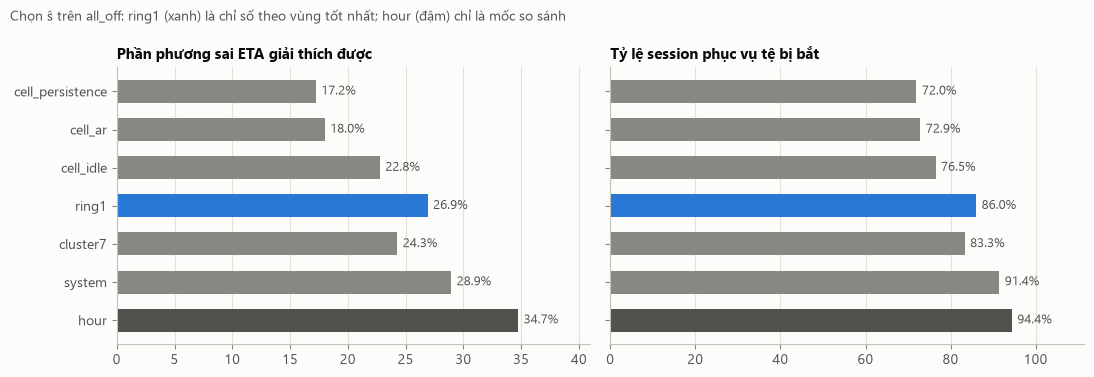

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
names = list(indicators.index)
colors = [C1 if n == "ring1" else (INK_2 if n == "hour" else MUTED) for n in names]
for ax, col, title in ((axes[0], "eta_r2", "Phần phương sai ETA giải thích được"),
                       (axes[1], "bad_capture", "Tỷ lệ session phục vụ tệ bị bắt")):
    v = 100 * indicators[col].to_numpy()
    ax.barh(np.arange(len(names)), v, color=colors, height=0.6)
    for i, x in enumerate(v):
        ax.annotate(f"{x:.1f}%", xy=(x, i), xytext=(4, 0), textcoords="offset points", va="center", color=INK_2, fontsize=9)
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", color=GRID)
    ax.set_xlim(0, 100 * indicators[col].max() * 1.18)
axes[0].set_yticks(np.arange(len(names)), names)
axes[0].invert_yaxis()
fig.suptitle("Chọn ŝ trên all_off: ring1 (xanh) là chỉ số theo vùng tốt nhất; hour (đậm) chỉ là mốc so sánh",
             x=0.01, ha="left", color=INK_2, fontsize=10)
fig.tight_layout()
save_figure(fig, "04_chon_s_hat")

- Đo ở **một ô** (`cell_*`) dự báo kém nhất: một ô 0,75 km có ít xe, slack nhảy mạnh giữa các slot.
- Gộp ô với 6 ô kề (**`ring1`**) tốt hơn hẳn và hơn cả cụm cố định 7 ô: vòng 1 luôn đặt ô của khách ở giữa, còn cụm cố định để nhiều ô nằm ở rìa.
- `system` (toàn thành phố) và `hour` dự báo tốt hơn nữa, nhưng sẽ bật/tắt voucher cả thành phố cùng lúc, mất quyết định theo vùng; `hour` chỉ phản ánh lịch ca cố định của mô phỏng (H-20).

Hai người chọn **ŝ = `ring1`** (H-25).

## 3. Voucher gây hại ở đâu, khi nào?

Voucher kéo thêm khách đặt xe. Lúc dư xe, khách thêm thành chuyến thêm. Lúc thiếu xe, khách thêm làm xe đi đón xa hơn, ETA tăng, nhiều khách bỏ cuộc trong lúc chờ, và số chuyến hoàn thành có thể **giảm**. So sánh trực tiếp nhất: cùng 5 seed, một lần **phát voucher cho mọi khách** và một lần **không phát cho ai**, không giới hạn ngân sách, đếm theo giờ.

In [9]:
on_off = theta.on_off_by_hour_runs(HOURLY_ON, HOURLY_OFF)
print(f"Cả ngày: phát cho mọi khách thêm {on_off['completed_diff'].sum():+.1f} chuyến so với không phát")
on_off.loc[3:10].round(2)

Cả ngày: phát cho mọi khách thêm +1198.8 chuyến so với không phát


,hour,completed_off,completed_diff,completed_diff_se,requests_diff,lost_diff,lost_rate_off,quoted_eta_off,quoted_eta_diff
3,3,45.4,20.2,2.71,20.2,0.0,0.03,3.10,0.19
4,4,46.6,17.6,2.48,20.2,2.6,0.04,4.11,0.62
5,5,54.2,3.6,3.14,14.2,10.6,0.18,8.30,4.93
6,6,64.4,0.4,3.33,28.0,27.6,0.24,12.34,3.36
7,7,116.6,-15.4,2.09,37.4,52.8,0.23,9.23,3.47
8,8,167.4,-6.4,6.81,52.0,58.4,0.12,6.36,3.87
9,9,154.8,31.0,5.59,63.0,32.0,0.08,5.36,2.39
10,10,153.2,49.8,3.69,61.4,11.6,0.05,4.17,1.14


WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/04_tac_hai_bat_tat_toan_bo.png')

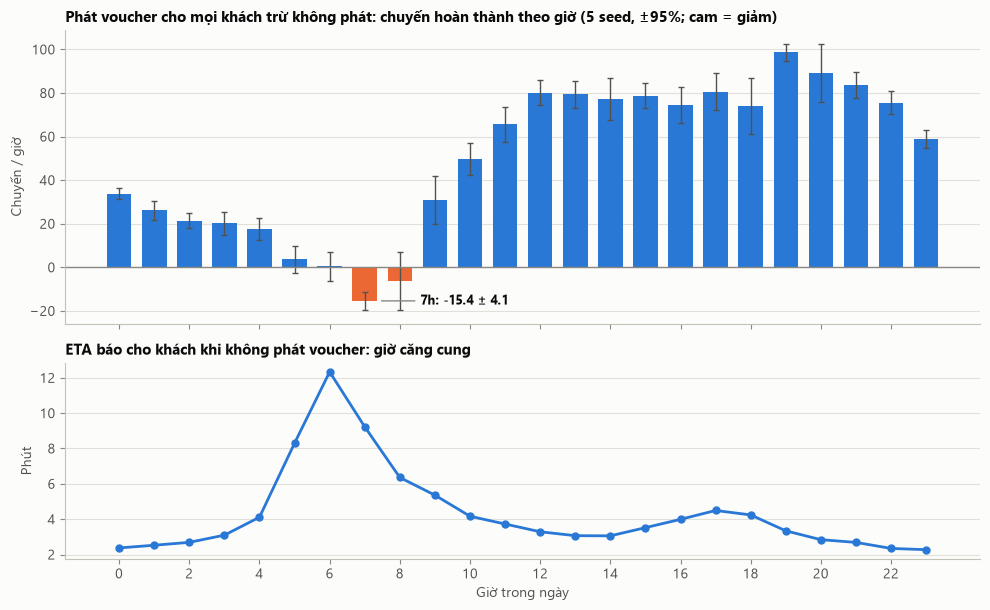

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True, height_ratios=[3, 2])
h = on_off["hour"].to_numpy()
d, se = on_off["completed_diff"].to_numpy(), on_off["completed_diff_se"].to_numpy()
ax1.bar(h, d, color=np.where(d < 0, C2, C1), width=0.7, yerr=1.96 * se,
        error_kw={"ecolor": INK_2, "elinewidth": 1, "capsize": 2})
ax1.axhline(0, color=MUTED, linewidth=1)
worst = int(np.argmin(d))
ax1.annotate(f"{h[worst]}h: {d[worst]:+.1f} ± {1.96 * se[worst]:.1f}", xy=(h[worst] + 0.4, d[worst]),
             xytext=(30, 0), textcoords="offset points", ha="left", va="center", color=INK, fontsize=9, fontweight="bold",
             arrowprops={"arrowstyle": "-", "color": MUTED, "linewidth": 1})
ax1.set_ylabel("Chuyến / giờ")
ax1.set_title("Phát voucher cho mọi khách trừ không phát: chuyến hoàn thành theo giờ (5 seed, ±95%; cam = giảm)")
ax2.plot(h, on_off["quoted_eta_off"], color=C1, linewidth=2, marker="o", markersize=5)
ax2.set_ylabel("Phút")
ax2.set_title("ETA báo cho khách khi không phát voucher: giờ căng cung")
ax2.set_xlabel("Giờ trong ngày")
ax2.set_xticks(range(0, 24, 2))
fig.tight_layout()
save_figure(fig, "04_tac_hai_bat_tat_toan_bo")

Voucher **làm giảm** số chuyến hoàn thành lúc 7h và 8h, đúng khung giờ ETA cao nhất; cả ngày vẫn tăng nhiều. Vậy tắt voucher theo giờ và nơi căng cung là có cơ sở.

Một thí nghiệm thật không chạy được "mọi khách / không ai" cùng lúc, mà luân phiên bật/tắt theo khối thời gian (**switchback**). Câu hỏi là luân phiên theo **cụm 7 ô** hay **cả thành phố**:

In [11]:
eff_all = theta.hour_effects(experiment_frame(SB_ALL), n_boot=300)
eff_c7 = theta.hour_effects(experiment_frame(SB_C7), n_boot=300)
by_hour = pd.concat({"toàn thành phố": theta.hour_table(eff_all), "cụm 7 ô": theta.hour_table(eff_c7)}, names=["thiết kế"])
by_hour.loc[(slice(None), slice(4, 9)), :].round(4)

hour     tau      lo      hi    cost
thiết kế                                              
toàn thành phố 4     4  0.0624  0.0422  0.0880  0.7764
               5     5 -0.0071 -0.0141  0.0000  0.3405
               6     6 -0.0048 -0.0095  0.0003  0.2608
               7     7 -0.0066 -0.0105 -0.0023  0.2964
               8     8 -0.0017 -0.0062  0.0025  0.4107
               9     9  0.0138  0.0099  0.0179  0.5476
cụm 7 ô        4     4  0.0635  0.0417  0.0866  0.7738
               5     5  0.0342  0.0225  0.0461  0.4102
               6     6  0.0226  0.0155  0.0309  0.3094
               7     7  0.0290  0.0222  0.0353  0.3775
               8     8  0.0414  0.0345  0.0487  0.5231
               9     9  0.0485  0.0408  0.0561  0.6591

WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/04_switchback_theo_gio.png')

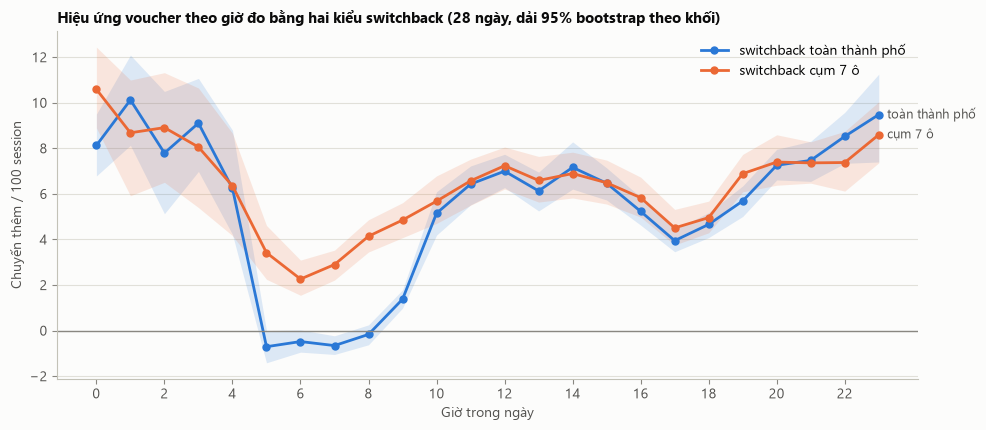

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.4))
for name, color in (("toàn thành phố", C1), ("cụm 7 ô", C2)):
    t = by_hour.loc[name]
    ax.fill_between(t["hour"], 100 * t["lo"], 100 * t["hi"], color=color, alpha=0.15, linewidth=0)
    ax.plot(t["hour"], 100 * t["tau"], color=color, linewidth=2, marker="o", markersize=5, label=f"switchback {name}")
    ax.annotate(name, xy=(23, 100 * t["tau"].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK_2, fontsize=9)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Chuyến thêm / 100 session")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=False, loc="upper right")
ax.set_title("Hiệu ứng voucher theo giờ đo bằng hai kiểu switchback (28 ngày, dải 95% bootstrap theo khối)")
fig.tight_layout()
save_figure(fig, "04_switchback_theo_gio")

- **Switchback toàn thành phố** thấy tác hại 5–8h (dưới 0, khoảng tin cậy lúc 7h nằm hẳn dưới 0), giống phép so "mọi khách / không ai".
- **Switchback cụm 7 ô** cho hiệu ứng **dương** ở cùng giờ. Cụm đang bật voucher mượn xe rảnh của cụm đang tắt bên cạnh, nên tác hại bị đẩy sang nhánh đối chứng và biến mất khỏi phép trừ. Đây là *interference* (vi phạm SUTVA), xem notebook 03.

Vì vậy hiệu ứng dùng để ước lượng θ̂ lấy từ **switchback toàn thành phố** (H-25 b).

## 4. Ước lượng θ̂ từ dữ liệu thí nghiệm (H-25 c)

Gán cho mỗi session trong một ngày `all_off` hiệu ứng τ(h) và chi phí voucher cost(h) của giờ của nó (từ switchback toàn thành phố), cùng giá trị `ring1` của nó. Chính sách cắt mọi session có `ring1` < θ. Hai cách chọn θ:

- **(A) chỉ tính tác hại:** θ̂_A = argmax Σ τ(h) trên các session còn bật. Không nhìn ngân sách: chỉ cắt khi τ < 0.
- **(B) có ngân sách:** θ̂_B = argmax min(B, S(θ)) × r(θ), với S(θ) là chi phí nếu phát cho mọi session còn bật và r(θ) = Σ τ / Σ cost là chuyến thêm mỗi USD ở đó. Cách này **giả định tầng rider phát ngẫu nhiên** trong vùng còn bật, nên cắt vùng kém hiệu quả để dồn tiền.

Khoảng tin cậy: bootstrap theo khối của τ(h) và cost(h).

In [13]:
meta = load_tables(ALL_OFF_3D, ["meta/run_metadata"])
n_days = frame["seed"].nunique() * run_config(meta)["time"]["window_min"] / 1440
GRID_THETA = np.r_[np.round(np.arange(0, 5.0001, 0.05), 2), 10.0, 30.0]
estimates = {c: theta.theta_hat(frame[c].to_numpy(), frame["hour"].to_numpy(), n_days, eff_all, B, GRID_THETA)
             for c in ("ring1", "system", "cell_persistence")}
pd.DataFrame({c: {"θ̂ (A)": r["theta_hat_A"], "CI (A)": r["ci_A"], "θ̂ (B)": r["theta_hat_B"], "CI (B)": r["ci_B"]}
              for c, r in estimates.items()}).T

,θ̂ (A),CI (A),θ̂ (B),CI (B)
ring1,0.25,"(0.15, 0.3)",5.0,"(5.0, 5.0)"
system,0.75,"(0.5, 0.95)",4.85,"(4.7, 4.85)"
cell_persistence,0.0,"(0.0, 0.0)",10.0,"(5.0, 10.0)"


WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/04_duong_loi_ich_theta_hat.png')

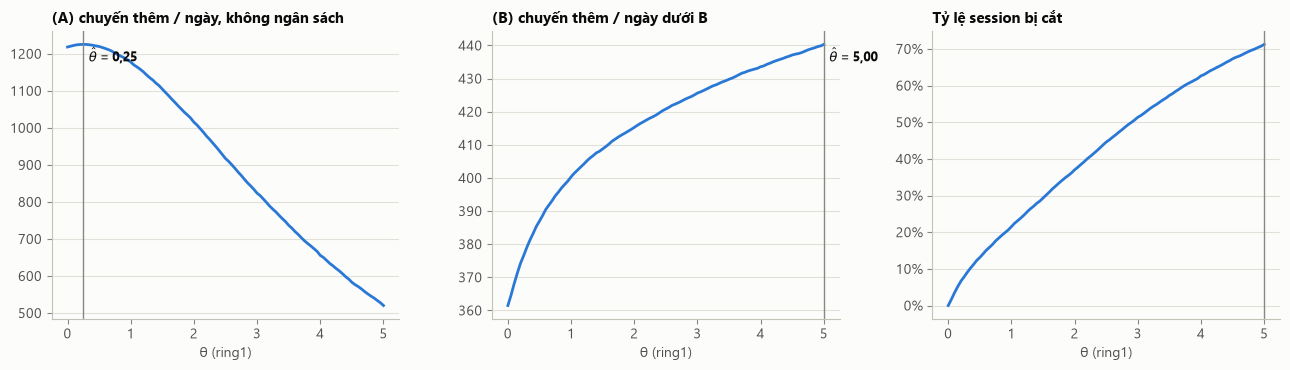

In [14]:
THETA_A, THETA_B = estimates["ring1"]["theta_hat_A"], estimates["ring1"]["theta_hat_B"]
curves = estimates["ring1"]["curves"]
curves = curves[curves["theta"] <= 5.0]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, title in ((axes[0], "gain_A", "(A) chuyến thêm / ngày, không ngân sách"),
                       (axes[1], "gain_B", "(B) chuyến thêm / ngày dưới B"),
                       (axes[2], "share_cut", "Tỷ lệ session bị cắt")):
    y = curves[col] * (100 if col == "share_cut" else 1)
    ax.plot(curves["theta"], y, color=C1, linewidth=2)
    best = THETA_A if col == "gain_A" else THETA_B
    ax.axvline(best, color=MUTED, linewidth=1)
    if col != "share_cut":
        ax.annotate(tex(f"θ̂ = {vn(best, 2)}"), xy=(best, float(y.max())), xytext=(4, -2), textcoords="offset points",
                    va="top", color=INK, fontsize=9, fontweight="bold")
    ax.set_title(title)
    ax.set_xlabel("θ (ring1)")
axes[2].yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
fig.tight_layout()
save_figure(fig, "04_duong_loi_ich_theta_hat")

WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/04_ti_le_cat_theo_gio.png')

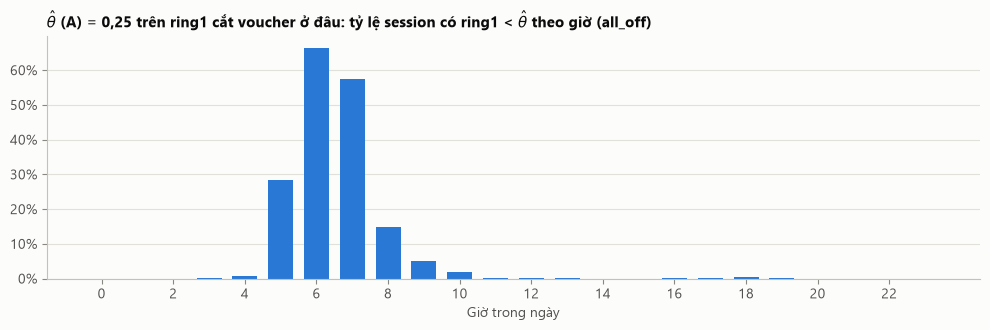

In [15]:
cut = frame.assign(cut=frame["ring1"] < THETA_A).groupby("hour")["cut"].mean()
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(cut.index, 100 * cut.to_numpy(), color=C1, width=0.7)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Giờ trong ngày")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.set_title(tex(f"θ̂ (A) = {vn(THETA_A, 2)} trên ring1 cắt voucher ở đâu: tỷ lệ session có ring1 < θ̂ theo giờ (all_off)"))
fig.tight_layout()
save_figure(fig, "04_ti_le_cat_theo_gio")

θ̂ (A) gần như chỉ cắt trong khung 5–8h, tức đúng giờ voucher gây hại; các giờ khác hầu như không bị đụng tới. Đo theo ô (`cell_persistence`) thì θ̂ (A) = 0: một ô đơn lẻ quá nhiễu để tách được giờ gây hại.

θ̂ (B) cắt rất mạnh (khoảng 70% session), vì nó coi việc cắt vùng là cách duy nhất để dồn tiền.

## 5. θ̂ so với θ\*: regret theo số chuyến (T-31, H-26)

θ\* không phải một số mà là **tập** các θ không kém θ tốt nhất (kiểm định ghép cặp theo seed, đã hiệu chỉnh so sánh bội). Một θ̂ được chấm bằng **regret**: N(θ tốt nhất) − N(θ̂), ghép cặp theo 30 seed. Ba sweep dùng ŝ = `ring1`, khác nhau ở hàm điểm của tầng rider.

WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/04_n_theo_theta_ring1.png')

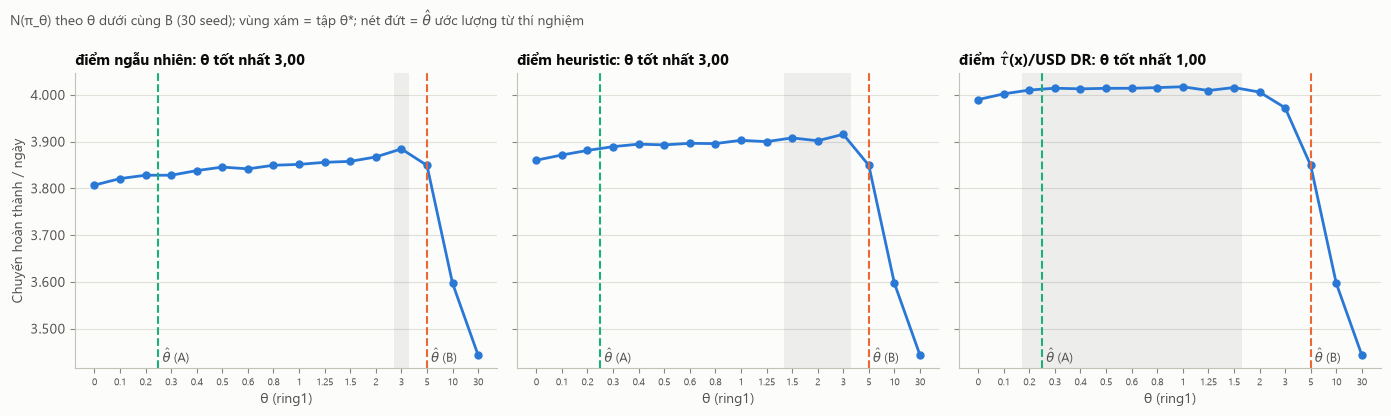

In [16]:
SWEEPS = {"ngẫu nhiên": SW_RING_RANDOM, "heuristic": SW_RING_HEUR, "τ̂(x)/USD DR": SW_RING_DR}
sweeps = {k: pd.read_parquet(p / "results" / "policy_results.parquet") for k, p in SWEEPS.items()}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, (name, runs) in zip(axes, sweeps.items()):
    mean = runs.groupby("theta")["N_completed"].mean()
    th = mean.index.to_numpy()
    x = np.arange(len(th))                                   # uneven grid: evenly spaced ticks, as in analysis.plots
    best, lo, hi = metrics.theta_star_interval(metrics.theta_star_set(runs))
    ax.axvspan(np.interp(lo, th, x) - 0.3, np.interp(hi, th, x) + 0.3, color=INK, alpha=0.06, linewidth=0)
    ax.plot(x, mean.to_numpy(), color=C1, linewidth=2, marker="o", markersize=5)
    for t_hat, label, color in ((THETA_A, "θ̂ (A)", C3), (THETA_B, "θ̂ (B)", C2)):
        ax.axvline(np.interp(t_hat, th, x), color=color, linewidth=1.5, linestyle="--")
        ax.annotate(tex(label), xy=(np.interp(t_hat, th, x), 0.02), xycoords=("data", "axes fraction"),
                    xytext=(3, 0), textcoords="offset points", color=INK_2, fontsize=9)
    ax.set_xticks(x, [f"{v:g}" for v in th], fontsize=7)
    ax.set_title(tex(f"điểm {name}: θ tốt nhất {vn(best, 2)}"))
    ax.set_xlabel("θ (ring1)")
    ax.yaxis.set_major_formatter(lambda v, _: vn(v))
axes[0].set_ylabel("Chuyến hoàn thành / ngày")
fig.suptitle(tex("N(π_θ) theo θ dưới cùng B (30 seed); vùng xám = tập θ*; nét đứt = θ̂ ước lượng từ thí nghiệm"),
             x=0.01, ha="left", color=INK_2, fontsize=10)
fig.tight_layout()
save_figure(fig, "04_n_theo_theta_ring1")

In [17]:
rows = []
for name, runs in sweeps.items():
    for label, t_hat in (("θ = 0 (không cắt ô)", 0.0), ("θ̂ (A)", THETA_A), ("θ̂ (B)", THETA_B)):
        r = metrics.sweep_regret(runs, t_hat)
        rows.append({"điểm": name, "ngưỡng": label, "θ": t_hat, "θ tốt nhất": r["theta_best"],
                     "regret": r["regret"], "SE": r["se"], "CI thấp": r["lo"], "CI cao": r["hi"],
                     "% của N tốt nhất": 100 * r["relative"]})
regret = pd.DataFrame(rows)
regret.round(2)

,điểm,ngưỡng,θ,θ tốt nhất,regret,SE,CI thấp,CI cao,% của N tốt nhất
0,ngẫu nhiên,θ = 0 (không cắt ô),0.00,3.0,77.43,5.73,65.71,89.16,1.99
1,ngẫu nhiên,θ̂ (A),0.25,3.0,56.33,5.18,45.75,66.92,1.45
2,ngẫu nhiên,θ̂ (B),5.00,3.0,35.27,5.66,23.68,46.85,0.91
3,heuristic,θ = 0 (không cắt ô),0.00,3.0,55.43,4.69,45.83,65.03,1.42
4,heuristic,θ̂ (A),0.25,3.0,30.48,4.21,21.87,39.10,0.78
5,heuristic,θ̂ (B),5.00,3.0,66.50,3.87,58.59,74.41,1.70
6,τ̂(x)/USD DR,θ = 0 (không cắt ô),0.00,1.0,27.43,4.10,19.05,35.82,0.68
7,τ̂(x)/USD DR,θ̂ (A),0.25,1.0,5.12,3.13,-1.29,11.52,0.13
8,τ̂(x)/USD DR,θ̂ (B),5.00,1.0,168.17,5.27,157.40,178.94,4.19


WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/04_regret_theta_hat.png')

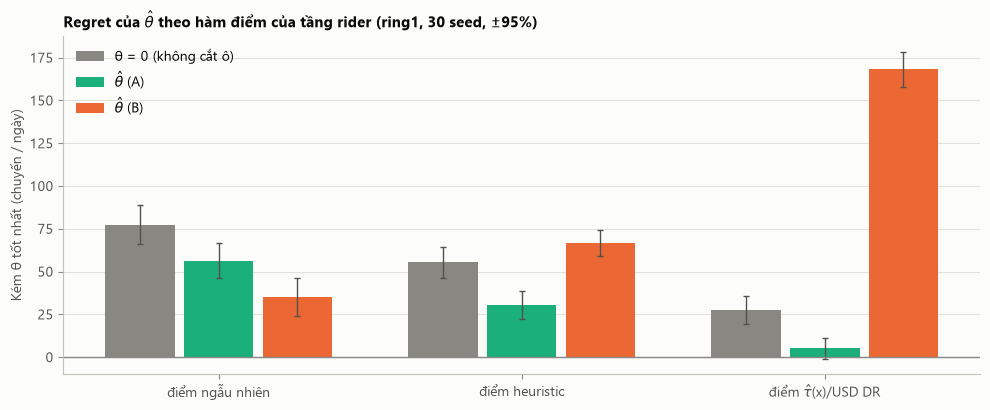

In [18]:
fig, ax = plt.subplots(figsize=(10, 4.2))
labels = ["θ = 0 (không cắt ô)", "θ̂ (A)", "θ̂ (B)"]
width = 0.26
for i, (label, color) in enumerate(zip(labels, (MUTED, C3, C2))):
    part = regret[regret["ngưỡng"] == label]
    x = np.arange(len(part)) + (i - 1) * width
    ax.bar(x, part["regret"], width=width - 0.03, color=color, label=tex(label), yerr=1.96 * part["SE"],
           error_kw={"ecolor": INK_2, "elinewidth": 1, "capsize": 2})
ax.set_xticks(np.arange(len(sweeps)), [tex(f"điểm {k}") for k in sweeps])
ax.set_ylabel("Kém θ tốt nhất (chuyến / ngày)")
ax.axhline(0, color=MUTED, linewidth=1)
ax.legend(frameon=False)
ax.set_title(tex("Regret của θ̂ theo hàm điểm của tầng rider (ring1, 30 seed, ±95%)"))
fig.tight_layout()
save_figure(fig, "04_regret_theta_hat")

Mỗi θ̂ đúng với loại tầng rider mà nó giả định (H-26):
- Với điểm **τ̂(x)/USD**, tầng rider đã tự dồn tiền vào khách hiệu quả, nên ngưỡng chỉ cần tránh tác hại. **θ̂ (A) gần như tối ưu** (khoảng tin cậy của regret chứa 0), còn θ̂ (B) cắt quá tay và mất nhiều chuyến nhất.
- Với **phát ngẫu nhiên**, ngưỡng phải gánh cả việc dồn ngân sách, nên θ̂ (B) tốt hơn θ̂ (A), dù vẫn vượt qua θ tốt nhất.

Vì sao (B) vượt: mô hình (B) ước chi phí "nếu phát cho mọi session còn bật" cao hơn thực tế, nên tưởng ngân sách vẫn chặn ở θ lớn. Ở các θ mà sweep phát cho mọi session còn bật (κ = −∞), so được trực tiếp:

In [19]:
kappa = pd.read_parquet(SW_RING_RANDOM / "meta" / "run_metadata.parquet").groupby("theta")["kappa"].first()
measured = sweeps["ngẫu nhiên"].groupby("theta")[["voucher_spent_usd"]].mean().assign(kappa=kappa)
model = estimates["ring1"]["curves"].set_index("theta")["spend_all_on"]
check = pd.DataFrame({"mô hình (B): chi nếu phát hết": model, "sweep: chi thực tế": measured["voucher_spent_usd"],
                      "κ của sweep": measured["kappa"]}).loc[[3.0, 5.0, 10.0]]
check["B"] = B
check.round(1)

,mô hình (B): chi nếu phát hết,sweep: chi thực tế,κ của sweep,B
theta,,,,
3.0,10731.2,5496.4,0.4,5545.8
5.0,6552.5,4936.6,-inf,5545.8
10.0,2238.0,1794.9,-inf,5545.8


Ở θ = 5 và 10, sweep phát cho mọi session còn bật (κ = −∞) nhưng chỉ chi khoảng 75–80% mức mô hình (B) dự báo. Một giả thuyết **chưa kiểm**: ŝ đo trên dữ liệu `all_off` cao hơn ŝ khi voucher bật (voucher thêm xe đi đón nên slack giảm), nên thực tế chính sách cắt nhiều hơn mô hình tính. Ở θ = 0 mô hình (B) khớp với đo thực tế (H-26).

## 6. Kết luận và chính sách khuyến nghị

In [20]:
FINAL = {"all_off": "không phát voucher", "all_on_B": "phát cho mọi khách đến khi hết B", "random": "ngẫu nhiên, θ = 0",
         "tau_x_dr_all_usd": "τ̂(x)/USD DR, θ = 0", "pi_thetahatA_ring1_dr_usd": "τ̂(x)/USD DR + ring1, θ̂ (A)",
         "pi_thetahatB_ring1_dr_usd": "τ̂(x)/USD DR + ring1, θ̂ (B)"}
final = summarize(policy_runs, reference="all_on_B", order=list(FINAL)).set_index("label")
final.assign(**{"chính sách": pd.Series(FINAL)})[["chính sách", "theta", "N_mean", "N_se", "dN_vs_ref", "dN_vs_ref_se",
                                                  "spent_mean", "share_cells_off"]].round(3)

,chính sách,theta,N_mean,N_se,dN_vs_ref,dN_vs_ref_se,spent_mean,share_cells_off
label,,,,,,,,
all_off,không phát voucher,NaN,3440.100,10.314,-246.633,5.195,0.000,1.000
all_on_B,phát cho mọi khách đến khi hết B,NaN,3686.733,10.288,0.000,0.000,5545.255,0.000
random,"ngẫu nhiên, θ = 0",0.00,3807.033,11.197,120.300,5.140,5451.661,0.000
tau_x_dr_all_usd,"τ̂(x)/USD DR, θ = 0",0.00,3989.933,10.121,303.200,6.697,5479.574,0.000
pi_thetahatA_ring1_dr_usd,"τ̂(x)/USD DR + ring1, θ̂ (A)",0.25,4011.767,11.795,325.033,5.795,5451.152,0.102
pi_thetahatB_ring1_dr_usd,"τ̂(x)/USD DR + ring1, θ̂ (B)",5.00,3849.200,9.126,162.467,6.198,4936.551,0.700


1. **Hàm điểm:** xếp rider theo **chuyến thêm mỗi USD**, không theo chuyến thêm mỗi lượt phát. Điểm theo lượt phát không hơn phát ngẫu nhiên dưới cùng ngân sách. Thông tin căng cung giúp thêm khoảng +20 chuyến/ngày, đưa vào điểm (τ̂(x, s)) hay vào tầng ô (`ring1`, θ̂ (A)) đều được như nhau.
2. **Chỉ số căng cung:** **`ring1`**, tức slack của ô gộp với 6 ô kề. Nó dự báo mức phục vụ tốt hơn slack từng ô và cụm cố định, mà vẫn quyết định theo vùng.
3. **Tác hại:** voucher làm giảm số chuyến hoàn thành lúc 7–8h khi xe thiếu. Chỉ **switchback toàn thành phố** đo được tác hại này; switchback theo cụm che mất nó do xe chạy giữa các cụm.
4. **Ngưỡng:** với điểm τ̂(x)/USD, **θ̂ (A) = 0,25** ước lượng từ thí nghiệm có regret khoảng 0,1% so với θ tốt nhất đo bằng mô phỏng. θ̂ phải ước lượng **cùng với hàm điểm sẽ chạy**: phát ngẫu nhiên cần ngưỡng cao hơn nhiều.
5. **Chính sách khuyến nghị** (H-26): ŝ = `ring1`, điểm `tau_x_dr_all_per_dollar`, θ = 0,25, ngang hàng tốt nhất trong bảng (cùng mức với τ̂(x, s)/USD ở θ = 0). Việc còn mở: kết hợp τ̂(x, s) học lại trên `ring1` với tầng ô (H-28). Chạy bằng
   `--set policy.threshold.scope=ring1 --set policy.threshold.score_fn=analysis.uplift:tau_x_dr_all_per_dollar --set policy.threshold.theta=0.25`.

**Giới hạn:** mọi kết quả trên một thế giới mô phỏng (`world_seed`) với lịch ca cố định; θ tốt nhất và tập θ\* chọn trên cùng các seed dùng để chấm regret (winner's curse); nhiễu do `u_latent` không gỡ được bằng dữ liệu quan sát (notebook 05).